
In Notebook 03, I modelled a Power-Recycled Michelson Interferometer (PRMI) and generated PDH error signals for interferometer control.

I introduced Fabry-Perot arm cavities to PRMI and investigated how cavity parameters affect optical power buildup and sensing performance. This kind of extended the basic PRMI towards a bit more aLIGO like interferometer.

Before that, I wanted to understand how ITM reflectivity and modulation parameters affect cavity and PDH sensitivity.

In [12]:
import finesse
import numpy as np
import matplotlib.pyplot as plt
from finesse.analysis.actions import Xaxis

finesse.configure(plotting=True)

### **1. Standalone Fabry-Perot Cavity**

I modelled a  Fabry-Perot cavity. The ETM phase is scanned around resonance to introduce a microscopic cavity length change.


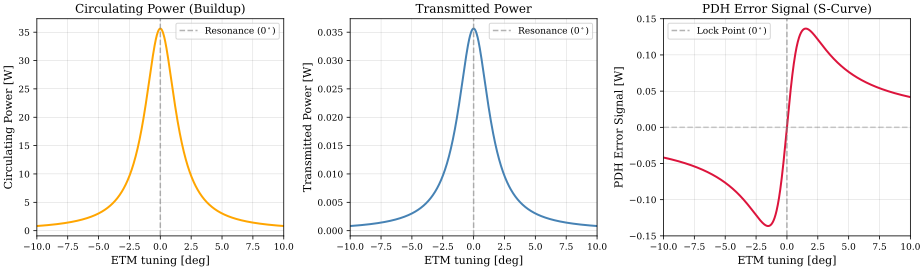

In [ ]:
fp_model = finesse.Model()
fp_model.parse("""
    l laser1 P=1

    # Modulator to create sidebands at 20 MHz for PDH
    s s1 laser1.p1 mod.p1 L=1
    modulator mod f=20M midx=0.3 order=1
    s s2 mod.p2 ITM.p1 L=5

    # Cavity Mirrors (ITM allows light in, ETM reflects it back)
    m ITM R=0.9 T=0.1 phi=0
    s cavity ITM.p2 ETM.p1 L=10
    m ETM R=0.999 T=0.001 phi=0

    # Detectors
    pd pow_circ ITM.p2.o         # Circulating power inside the cavity
    pd pow_trans ETM.p2.o        # Transmitted power out the back
    pd1 PDH_refl ITM.p1.o 20M 0  # PDH error signal at the reflection port
""")

out_fp = fp_model.run(Xaxis("ETM.phi", "lin", -10, 10, 1000))


fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(out_fp.x[0], out_fp['pow_circ'], color='orange', linewidth=2)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.6, label='Resonance ($0^\\circ$)')
axes[0].set_ylabel('Circulating Power [W]')
axes[0].set_xlabel('ETM tuning [deg]')
axes[0].set_title('Circulating Power (Buildup)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(out_fp.x[0], out_fp['pow_trans'], color='steelblue', linewidth=2)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.6, label='Resonance ($0^\\circ$)')
axes[1].set_ylabel('Transmitted Power [W]')
axes[1].set_xlabel('ETM tuning [deg]')
axes[1].set_title('Transmitted Power')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(out_fp.x[0], out_fp['PDH_refl'], color='crimson', linewidth=2)
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.6, label='Lock Point ($0^\\circ$)')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.4)
axes[2].set_ylabel('PDH Error Signal [W]')
axes[2].set_xlabel('ETM tuning [deg]')
axes[2].set_title('PDH Error Signal (S-Curve)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. The circulating power shows resonance peak at zero operating point. At this point, successive reflections interfere constructively, allowing optical power to build up inside the cavity.

2. The transmitted power reaches its maximum value at resonance. As the cavity moves away from resonance, constructive interference is reduced and both circulating and transmitted power decrease.

3. The PDH error signal is antisymmetric S-shape. The zero-crossing corresponds to the cavity resonance condition and provides the operating point for feedback control.

## **2. ITM Reflectivity**

The reflectivity of the ITM determines how strongly light is stored within the cavity. I vaied the ITM reflectivity while keeping the remaining cavity parameters fixed.

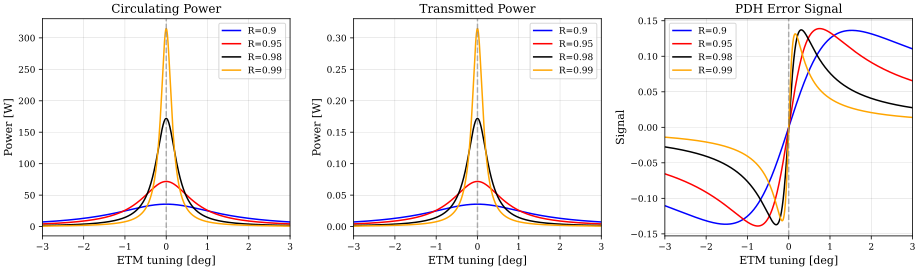


RESULTS

ITM R     Peak Power     PDH Slope      
0.90      35.633         1.7896e-01     
0.95      71.748         3.7093e-01     
0.98      171.883        9.0283e-01     
0.99      314.785        1.6615e+00     


In [ ]:
ITM_R_values = [0.90, 0.95, 0.98, 0.99]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
results = []

for R in ITM_R_values:
    model = finesse.Model()
    model.parse(f"""
        l laser1 P=1
        s s1 laser1.p1 mod.p1 L=1
        modulator mod f=20M midx=0.3 order=1
        s s2 mod.p2 ITM.p1 L=5
        m ITM R={R} T={1-R} phi=0
        s cavity ITM.p2 ETM.p1 L=10
        m ETM R=0.999 T=0.001 phi=0
        pd  pow_circ  ITM.p2.o
        pd  pow_trans ETM.p2.o
        pd1 PDH_refl ITM.p1.o 20M 0
    """)

    out = model.run(Xaxis("ETM.phi", "lin", -3, 3, 2000))
    x = out.x[0]
    circ = out["pow_circ"]
    pdh = out["PDH_refl"]

    #peak circulating power
    peak_power = np.max(circ)

    #PDH slope
    center = np.argmin(np.abs(x))
    slope = (pdh[center + 1] - pdh[center - 1]) / (x[center + 1] - x[center - 1])
    results.append([R, peak_power, slope])


    axes[0].plot(x, circ, label=f"R={R}")
    axes[1].plot(x, out["pow_trans"], label=f"R={R}")
    axes[2].plot(x, pdh, label=f"R={R}")

axes[0].set_title("Circulating Power")
axes[0].set_xlabel("ETM tuning [deg]")
axes[0].set_ylabel("Power [W]")
axes[0].grid(True, alpha=0.3)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.6)
axes[0].legend()

axes[1].set_title("Transmitted Power")
axes[1].set_xlabel("ETM tuning [deg]")
axes[1].set_ylabel("Power [W]")
axes[1].grid(True, alpha=0.3)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.6)
axes[1].legend()

axes[2].set_title("PDH Error Signal")
axes[2].set_xlabel("ETM tuning [deg]")
axes[2].set_ylabel("Signal")
axes[2].grid(True, alpha=0.3)
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nRESULTS\n")
print(f"{'ITM R':<10}{'Peak Power':<15}{'PDH Slope':<15}")

for row in results:
    print(f"{row[0]:<10.2f}{row[1]:<15.3f}{row[2]:<15.4e}")

As the ITM reflectivity increases,

- The circulating power peak becomes significantly larger while the resonance width becomes narrower. This occurs because light remains stored inside the cavity for a larger number of round trips.

- The PDH error signal is a steeper slope near the operating point. This shows improved sensitivity to small cavity length change.

## **3. Effect of Modulation Frequency**

As PDH relies on RF sidebands generated through phase modulation of laser, the modulation freq. determines the spectral separation and influence the error signal.


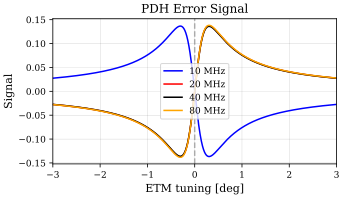


RESULTS

f_mod (MHz)    PDH Slope      
10             -8.9930e-01    
20             9.0283e-01     
40             8.9576e-01     
80             9.0987e-01     


In [ ]:
mod_freqs = [10e6, 20e6, 40e6, 80e6]

fig, ax = plt.subplots(figsize=(5,3))
results = []

for fmod in mod_freqs:

    model = finesse.Model()
    model.parse(f"""
        l laser1 P=1

        s s1 laser1.p1 mod.p1 L=1
        modulator mod f={fmod} midx=0.3 order=1
        s s2 mod.p2 ITM.p1 L=5

        m ITM R=0.98 T=0.02 phi=0

        s cavity ITM.p2 ETM.p1 L=10

        m ETM R=0.999 T=0.001 phi=0

        pd1 PDH_refl ITM.p1.o {fmod} 0
    """)

    out = model.run(Xaxis("ETM.phi", "lin", -3, 3, 2000))

    x = out.x[0]
    pdh = out["PDH_refl"]
    center = np.argmin(np.abs(x))
    slope = (pdh[center+1] - pdh[center-1]) / (x[center+1] - x[center-1])

    results.append([fmod/1e6, slope])


    ax.plot(x, pdh, label=f"{fmod/1e6:.0f} MHz")


ax.axvline(0, color='gray', linestyle='--', alpha=0.6)
ax.grid(True, alpha=0.3)
ax.set_title("PDH Error Signal")
ax.set_xlabel("ETM tuning [deg]")
ax.set_ylabel("Signal")
ax.legend()

plt.tight_layout()
plt.show()

print("\nRESULTS\n")
print(f"{'f_mod (MHz)':<15}{'PDH Slope':<15}")
for row in results:
    print(f"{row[0]:<15.0f}{row[1]:<15.4e}")

- The magnitude of the slope ~ constant.

- For 10 MHz, we have a negative slope whereas for the higher-frequency cases we have positive slopes.

- The results suggest that, for this cavity configuration, modulation frequencies between 10 MHz and 80 MHz are all capable of producing a usable PDH error signal.

## **4. Effect of Modulation Index**

The modulation index controls how much optical power is transferred from the carrier into the RF sidebands.

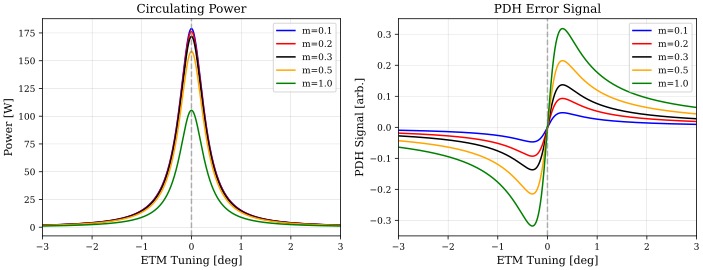

Mod Index      Peak Power     PDH Slope      
0.10           178.943        3.1015e-01     
0.20           176.270        6.1335e-01     
0.30           171.883        9.0283e-01     
0.50           158.391        1.4156e+00     
1.00           105.304        2.0966e+00     


In [ ]:
mod_indices = [0.1, 0.2, 0.3, 0.5, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results = []

for midx in mod_indices:

    model = finesse.Model()
    model.parse(f"""
        l laser1 P=1

        s s1 laser1.p1 mod.p1 L=1
        modulator mod f=20M midx={midx} order=1
        s s2 mod.p2 ITM.p1 L=5

        m ITM R=0.98 T=0.02 phi=0

        s cavity ITM.p2 ETM.p1 L=10

        m ETM R=0.999 T=0.001 phi=0

        pd  pow_circ  ITM.p2.o

        pd1 PDH_refl ITM.p1.o 20M 0
    """)

    out = model.run(Xaxis("ETM.phi", "lin", -3, 3, 2000))

    x = out.x[0]
    circ = out["pow_circ"]
    pdh = out["PDH_refl"]

    # Peak circulating power
    peak_power = np.max(circ)

    # PDH slope around resonance
    center = np.argmin(np.abs(x))
    slope = (pdh[center + 1] - pdh[center - 1]) / (
        x[center + 1] - x[center - 1]
    )

    results.append([midx, peak_power, slope])

    axes[0].plot(x, circ, label=f"m={midx}")
    axes[1].plot(x, pdh, label=f"m={midx}")

# Formatting
for ax in axes:
    ax.axvline(0, color="gray", linestyle="--", alpha=0.6)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Circulating Power")
axes[0].set_xlabel("ETM Tuning [deg]")
axes[0].set_ylabel("Power [W]")
axes[0].legend()

axes[1].set_title("PDH Error Signal")
axes[1].set_xlabel("ETM Tuning [deg]")
axes[1].set_ylabel("PDH Signal [arb.]")
axes[1].legend()

plt.tight_layout()
plt.show()

# Results table
print(f"{'Mod Index':<15}{'Peak Power':<15}{'PDH Slope':<15}")

for row in results:
    print(f"{row[0]:<15.2f}{row[1]:<15.3f}{row[2]:<15.4e}")

- A small modulation index transfers only a small fraction of the optical power into the RF sidebands, resulting in a relatively weak error signal.

 - Increasing the modulation index strengthens the sidebands and increases the PDH slope, but simultaneously reduces the carrier power.

- As the modulation index increases we can see from the plots,

  - The peak circulating power decreases from ~ 179 W to 105 W. This is because a larger fraction of the laser power is transferred from the carrier into the RF sidebands.

  - The PDH slope increases significantly. The stronger sidebands produce a larger demodulated error signal and therefore increase the sensitivity of the PDH readout.

- For GW detectors, modulation index are chosen such that it balances PDH slope against carrier power.

## **5. PRMI along with FP cavity**
I incorporate Fabry-Perot cavities into the Power-Recycled Michelson Interferometer developed in Notebook 03. I tried studying the differential arm length (DARM) DoF.

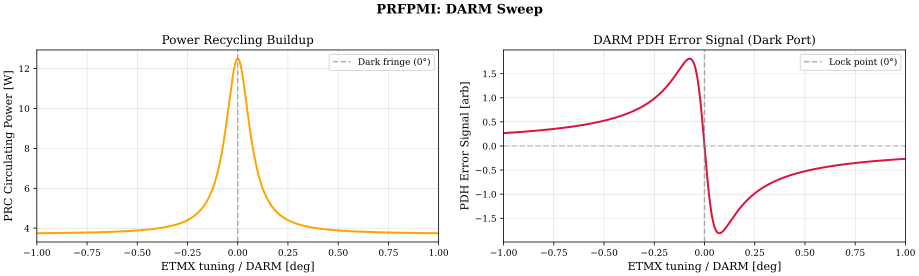

In [23]:
prm_fp = finesse.Model()
prm_fp.parse('''
    l laser1 P=125

    s s1 laser1.p1 mod.p1 L=1
    modulator mod f=80M midx=0.3 order=1
    s s2 mod.p2 PRM.p1 L=9

    m PRM R=0.9 T=0.1 phi=0

    s s_prc PRM.p2 bs1.p1 L=40
    bs bs1 R=0.5 T=0.5

    # X arm Fabry-Perot cavity
    s s_itmX bs1.p3 ITMX.p1 L=5
    m ITMX R=0.99 T=0.01 phi=0
    s armX ITMX.p2 ETMX.p1 L=4000
    m ETMX R=1.0 T=0.0 phi=0

    # Y arm Fabry-Perot cavity
    s s_itmY bs1.p2 ITMY.p1 L=5
    m ITMY R=0.99 T=0.01 phi=0
    s armY ITMY.p2 ETMY.p1 L=4000
    m ETMY R=1.0 T=0.0 phi=0

    # Detectors
    pd  pow_circ  PRM.p2.o           # Circulating power in PRC (right side of PRM)
    pd  pow_armX  ITMX.p2.o         # X arm circulating power (inside cavity)

    pd1 PDH_dark  bs1.p4.o  80M 90  # DARM error signal (dark port)
''')


out = prm_fp.run(Xaxis("ETMX.phi", "lin", -1, 1, 1000))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("PRFPMI: DARM Sweep", fontsize=13, fontweight='bold')


axes[0].plot(out.x[0], out['pow_circ'], color='orange', linewidth=2)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.6, label='Dark fringe (0°)')
axes[0].set_ylabel('PRC Circulating Power [W]')
axes[0].set_xlabel('ETMX tuning / DARM [deg]')
axes[0].set_title('Power Recycling Buildup')
axes[0].legend(); axes[0].grid(True, alpha=0.3)


axes[1].plot(out.x[0], out['PDH_dark'], color='crimson', linewidth=2)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.6, label='Lock point (0°)')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.4)
axes[1].set_ylabel('PDH Error Signal [arb]')
axes[1].set_xlabel('ETMX tuning / DARM [deg]')
axes[1].set_title('DARM PDH Error Signal (Dark Port)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- PRC shows maximum circulating power near the operating point, indicating strong optical buildup within the coupled cavity system.

- DARM PDH signal is antisymmetric S-slope. Steep slope indicates the sensitivity to small differential arm displacements.




Notebook 03 showed how to sense interferometer degrees of freedom using PDH signals. In this notebook, I explored FP cavity as the next step toward a realistic aLIGO style interferometer and examined how cavity parameters influence both optical power storage and DARM sensing performance.